# **Neural Network Classification**
### Creating the Classification model

In [ ]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
#1. Making the Custom Dataset For the classification
from sklearn.datasets import make_circles

#2. creating the Dataset

n_samples = 1000
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

len(X), len(y)

(1000, 1000)

## Inspecting the data

In [ ]:
#1. inspecting the data
print(f"{X[:5]}")
print(f"{y[:5]}")

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
[1 1 1 1 0]


In [ ]:
#1. Making the Daraframe
import pandas as pd
circles = pd.DataFrame({"x1":X[: , 0],
                      "x2":X[:,1],
                       "labels":y})

In [ ]:
circles.head()

,x1,x2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


### **Visualizing the Data**

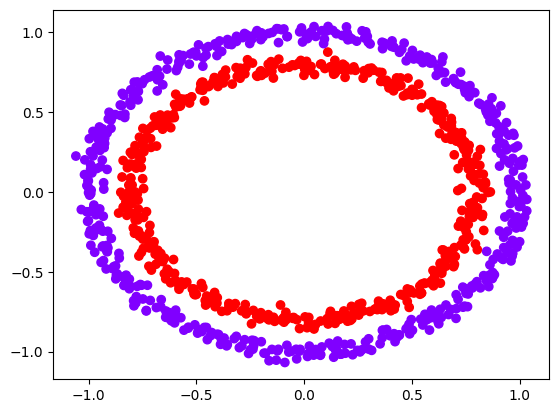

In [ ]:
#. Visualizing the data
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y,
            cmap = 'rainbow')

In [ ]:
#1. Converting the datainto tensors

# 1.1 Checking the input and output shapes
print(X.shape)
print(y.shape)
print(type(X))
print(type(y))

(1000, 2)
(1000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
#1. converting the numpy array to tensors

## 1. checking the torch version
torch.__version__

## 2. converting the X to tensor
X = torch.from_numpy(X).type(torch.float32)
print(type(X))

## 3. converting the y to tensor
y = torch.from_numpy(y).type(torch.float32)
print(type(y))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [ ]:
#1. printing the values of the data
print(f"First five values : {X[0:5]}")
print(f"First five values of y : {y[0:5]}")

First five values : tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])
First five values of y : tensor([1., 1., 1., 1., 0.])


In [ ]:
## 1. this split is for practice

# 1. Splitting data ito test and train
split = int(0.8 * len(X))

#2. splitting the training data
xtrain , ytrain = X[:split], y[:split]
#3. Splitting the test data
xtest, ytest = X[split:], y[split:]

len(xtrain), len(ytrain), len(xtest), len(ytest)

(800, 800, 200, 200)

In [ ]:
#1. splitting the data from the skleanr lib
from sklearn.model_selection import train_test_split

# 1.1 splitting the data
X_train , X_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       test_size = 0.2,
                                                       random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# *Building the PyTorch Model*

building the model to clasiffy the purple and red dots from the datasets  

In [ ]:
# 1. setting up a agnostic code for device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Now we've setup the agnostic code let's create the model

1. Subclass `nn.Module` (almost all model in PyTorch is subclass `nn.Module`)

2. Create 2 `nn.Linear()` capable of handling the shapes of our data

3. define a  `forward()` method that outline the forward pass



In [ ]:
X_train.shape

torch.Size([800, 2])

In [ ]:
from matplotlib.collections import CircleCollection
# 1. Construct the model that class is nn.Module

class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    # 1.1 creating a 2 nn.Linear layer handling the shapes of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

    # 1.2 creating the Forward pass
    def forward(self, x):
      return self.layer_2(self.layer_1(x)) ## --> X goes in layer_1 and layer_1 goes to layer_2 and layer_2 to output ### x-->layer_1-->layer_2

# 2. instantiate an instance of our model class and send it to target class
model = CircleModel().to(device)
model

CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# 1. let's replicate the model using the nn.sequential
model = nn.Sequential(
    nn.Linear(in_features=2 , out_features=5),
    nn.Linear(in_features=5, out_features=1)

).to(device)
model

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.6384,  0.6822],
                      [ 0.5851, -0.0048],
                      [-0.0851,  0.2891],
                      [-0.1776,  0.2422],
                      [-0.6498,  0.4514]])),
             ('0.bias', tensor([-0.6321,  0.6619, -0.5030,  0.0601,  0.4377])),
             ('1.weight',
              tensor([[ 0.3039, -0.2643,  0.0385, -0.1976,  0.3002]])),
             ('1.bias', tensor([-0.0419]))])

In [ ]:
# 1. Make predicyions

with torch.inference_mode():
  untrained_pred = model(X_test.to(device))

print(f"length {len(untrained_pred)} , shape is {untrained_pred.shape}")
print(f"length {len(X_test)} , shape {untrained_pred.shape}")

print(torch.round(untrained_pred[:10]))
print(y_test[:10])


length 200 , shape is torch.Size([200, 1])
length 200 , shape torch.Size([200, 1])
tensor([[ 0.],
        [-0.],
        [-0.],
        [ 0.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-0.],
        [-0.]])
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### reading --

`torch.nn.BCEWithLogitsLoss` **VS** `torch.nn.BCELoss`
### PyTorch Loss Functions: BCELoss vs. BCEWithLogitsLoss

**1. Input Expectation**

* **nn.BCELoss:** Expects Probabilities (Numbers strictly between 0 and 1).
* **nn.BCEWithLogitsLoss:** Expects Raw Logits (Unbounded scores from negative infinity to positive infinity).

**2. Sigmoid Integration**

* **nn.BCELoss:** No. You must apply the Sigmoid function yourself beforehand.
* **nn.BCEWithLogitsLoss:** Yes. It applies the Sigmoid function internally under the hood.

**3. Last Layer of Your Neural Network**

* **nn.BCELoss:** Must end with an activation layer like nn.Sigmoid().
* **nn.BCEWithLogitsLoss:** Must end with a plain nn.Linear() layer (no activation).

**4. Mathematical Safety**

* **nn.BCELoss:** Lower. Can cause computer math errors (NaN or Inf) if probabilities get too close to 0 or 1.
* **nn.BCEWithLogitsLoss:** Higher. Uses a mathematical shortcut trick that makes it highly stable.

**5. Standard Industry Choice**

* **nn.BCELoss:** Rarely used in modern workflows.
* **nn.BCEWithLogitsLoss:** The Gold Standard. Highly recommended by the PyTorch team.

*Important to read*  --> https://docs.pytorch.org/docs/2.12/nn.html

In [ ]:
# 1. picking up the Loss function
    # 1.i So for the Clasification model we need a binary cross entropy or  cross entropy
    # 1.ii Binary cross Entropy and Log loss are the Same thing
    # 1.iii BCE/ logloss what it does intuitivily that every Right label predicted  wrong  gets the higher penalty and the Log Convert the error

# 2. Selecting the loss function
loss_func = torch.nn.BCEWithLogitsLoss() # *no need of the nn.sigmoid With this

# 3. selecting the Optimizer
optimizer =  torch.optim.SGD(params=model.parameters(),
                             lr=0.1)


# Building the Training loop

### *Training loop*
1. model into train mode
2. Forward pass --> *on X_train*
3. Calculate loss -- *on y_pred , y_train*
4. optim.grad_zero()
5. backprop -> backward pass
6. setup optmizer (optim.step(0))

### *Testing Loop*
1. model in eval mode --> *X_test*
2. calculating the test loss

In [ ]:
torch.manual_seed(42)
device

'cpu'

In [ ]:
# 1. defining the accuracy function
def accuracy_fn(y_true , y_pred):
  correct = torch.eq(y_true , y_pred).sum().item()
  return (correct / len(y_pred)) * 100

# 2. Start the Model training
  # 2.i setting few values
epochs = 100

  # 2.ii Start the Model Training

for epoch in range(epochs):
  ### Trainng

  # i. putting model into train mode
  model.train()

  # ii. setting the foward pass
  y_logits = model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # iii. calculating the loss and accuracy
  loss = loss_func(y_logits , y_train)
  acc = accuracy_fn(y_true= y_train, y_pred=y_pred)

  # iv. optimizer grad to zero
  optimizer.zero_grad()

  # v. setting the Bakward pass
  loss.backward()

  # vi. setting the optimizer
  optimizer.step()

  # 2.iii Setting the testing loop

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # i. test loss and accuracy
    test_loss = loss_func(test_logits , y_test)
    test_acc = accuracy_fn(y_true=y_test , y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch : {epoch} | loss : {loss:.5f} | acc : {acc:.2f}% | test_loss : {test_loss:.5f} | test_acc : {test_acc:.2f}%")




Epoch : 0 | loss : 0.72294 | acc : 48.25% | test_loss : 0.71860 | test_acc : 45.50%
Epoch : 10 | loss : 0.70606 | acc : 49.62% | test_loss : 0.70455 | test_acc : 45.50%
Epoch : 20 | loss : 0.70018 | acc : 50.00% | test_loss : 0.69947 | test_acc : 47.50%
Epoch : 30 | loss : 0.69763 | acc : 50.25% | test_loss : 0.69713 | test_acc : 50.00%
Epoch : 40 | loss : 0.69628 | acc : 49.88% | test_loss : 0.69580 | test_acc : 51.50%
Epoch : 50 | loss : 0.69544 | acc : 49.62% | test_loss : 0.69493 | test_acc : 52.00%
Epoch : 60 | loss : 0.69487 | acc : 49.62% | test_loss : 0.69433 | test_acc : 51.50%
Epoch : 70 | loss : 0.69446 | acc : 50.12% | test_loss : 0.69390 | test_acc : 51.00%
Epoch : 80 | loss : 0.69417 | acc : 49.88% | test_loss : 0.69358 | test_acc : 50.50%
Epoch : 90 | loss : 0.69396 | acc : 50.38% | test_loss : 0.69336 | test_acc : 50.50%


from this perspective model isn't learning anything
so inspect them and lets make this visually

visualizing what is going on

to do this we are goin to import the function called `plot_decision_boundary()`

In [ ]:
import requests
from pathlib import Path

# 1. download the helper function if it is not already dowloaded
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

  from helper_functions import plot_predictions , plot_decision_boundary

  print(f"Download and import done")

Download and import done


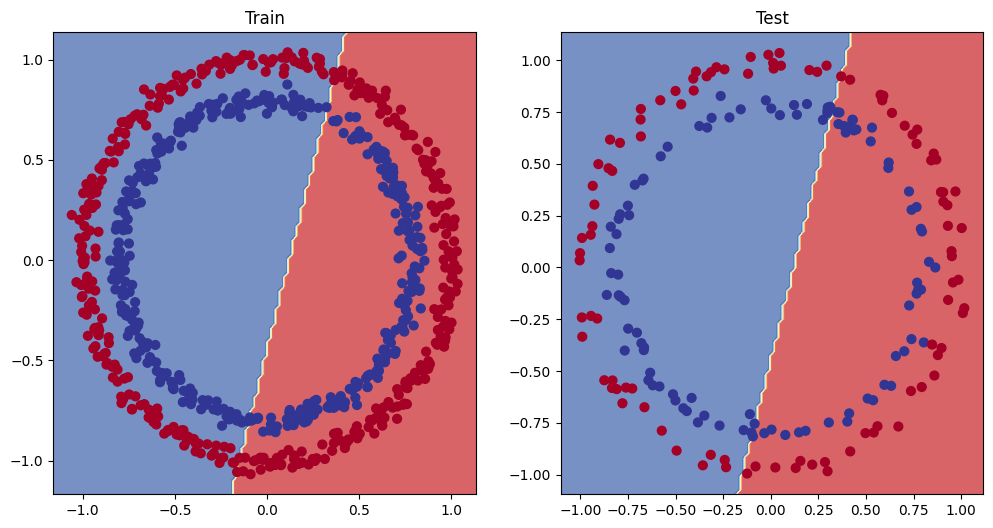

In [ ]:
# 1. plot the decison boundries of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model=model, X=X_train, y=y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model , X_test, y_test)

#Improving a Model
*these are all Hyperparamrters*
* Add more layers - give model more chances to learn about the patterns of the data

* Add more hidden units - Like this model has 5 hidden units , and go from these 5 to 10 , to 20

* Fit For longer , increasing the epochs

* change the Activation Function (this is using simple step/sigmoid function)

* changing the Learning Rate

* Change the loss function

These options are all from the model'sperspective and deal directly with the model

In [ ]:
# 1. creating the new model
# improving the model by increasing the layers and hidden features
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer3(self.layer2(self.layer1(x)))

modelv1 = CircleModelV1()

In [ ]:
modelv1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# 1. creating the training loop

epochs = 1000

for epoch in range(epochs):
  modelv1.train() # 1. putting here in training mode

  # 2. setting the forward pass
  y_logits = modelv1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 3. loss function
  loss = loss_func(y_logits , y_train)
  acc = accuracy_fn(y_true=y_train , y_pred=y_pred)

  # 4. Zero grad
  optimizer.zero_grad()

  # 5. Backprop
  loss.backward()

  # 6. step optim
  optimizer.step()

  #tesring llop
  modelv1.eval()
  with torch.inference_mode():
    test_logits = modelv1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_func(test_logits , y_test)
    test_acc = accuracy_fn(y_true=y_test , y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"Epoch : {epoch} | loss : {loss:.5f} | acc : {acc:.2f}% | test_loss : {test_loss:.5f} | test_acc : {test_acc:.2f}%")


Epoch : 0 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 100 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 200 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 300 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 400 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 500 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 600 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 700 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 800 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%
Epoch : 900 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261 | test_acc : 51.00%


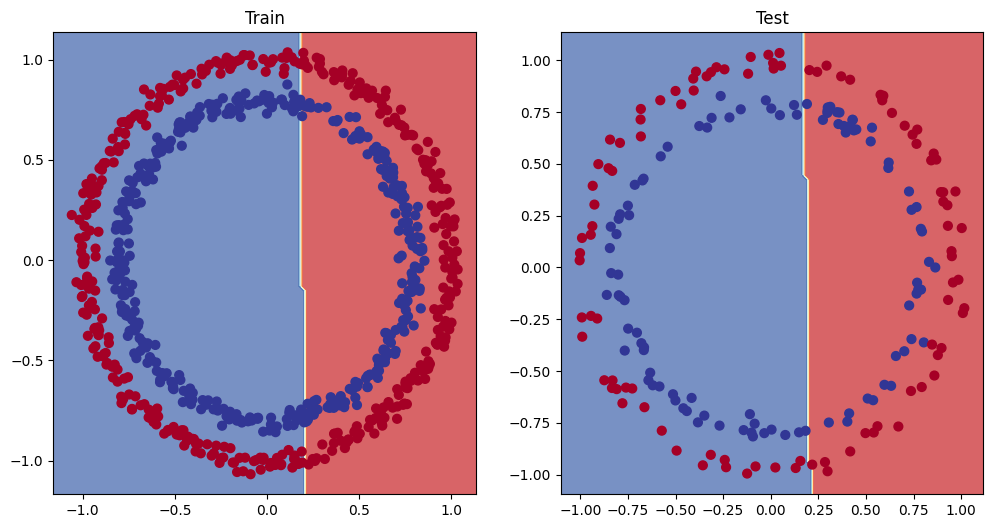

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model=modelv1, X=X_train, y=y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(modelv1 , X_test, y_test)

One way to troubleshoot to larger problem is to trouble shoot a smaller problem.

Solving this it with the Non Linearity

In [ ]:
# 1. building the modl with Non Linear Activation Function
# *nn.ReLU() function*

class circlemodel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(2,10)
    self.layer2 = nn.Linear(10,10)
    self.layer3 = nn.Linear(10,1)
    self.relu = nn.ReLU()
  def forward(self, x):
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

modelv2 = circlemodel()
modelv2

circlemodel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
#creating the Training and testing loop
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=modelv2.parameters(),
                            lr=0.1)

#training loop

epochs = 2000
epoch_counts = []
test_loss_val = []
train_loss_val = []
for epoch in range(epochs):
  # 1. training loop
  modelv2.train()

  #forward pass
  y_logits = modelv2(X_train).squeeze()

  #loss fn
  loss = loss_fn(y_logits , y_train)
  #optimizer
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #testing loop
  modelv2.eval()
  with torch.inference_mode():
    test_preds = modelv2(X_test).squeeze()
    test_loss = loss_fn(test_preds, y_test)

  if epoch % 200 == 0:
    epoch_counts.append(epoch)
    test_loss_val.append(test_loss.detach().numpy())
    train_loss_val.append(loss.detach().numpy())
    print(f"Epoch : {epoch} | loss : {loss:.5f} | test_loss : {test_loss:.5f} ")

Epoch : 0 | loss : 0.69441 | test_loss : 0.69360 
Epoch : 200 | loss : 0.69074 | test_loss : 0.68922 
Epoch : 400 | loss : 0.68863 | test_loss : 0.68614 
Epoch : 600 | loss : 0.68575 | test_loss : 0.68246 
Epoch : 800 | loss : 0.68108 | test_loss : 0.67768 
Epoch : 1000 | loss : 0.67298 | test_loss : 0.67067 
Epoch : 1200 | loss : 0.65590 | test_loss : 0.65706 
Epoch : 1400 | loss : 0.60738 | test_loss : 0.61813 
Epoch : 1600 | loss : 0.44890 | test_loss : 0.47627 
Epoch : 1800 | loss : 0.21187 | test_loss : 0.24666 


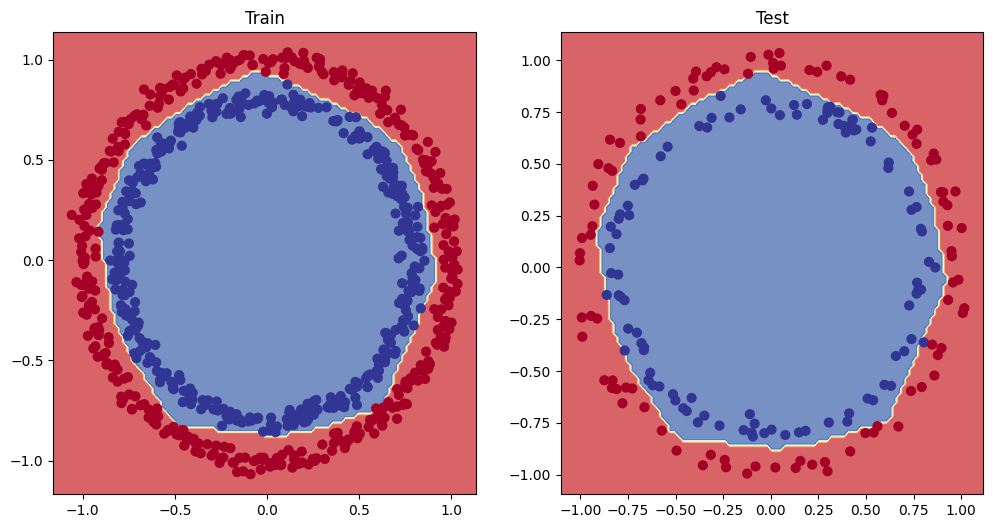

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model=modelv2, X=X_train, y=y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(modelv2, X_test, y_test)

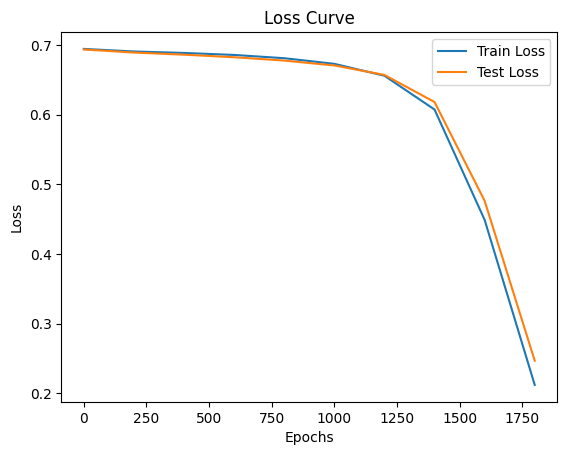

In [ ]:
#code for the loss curve

plt.plot(epoch_counts, train_loss_val, label="Train Loss")
plt.plot(epoch_counts, test_loss_val, label="Test Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 1. Evaluating the Model
modelv2.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(modelv2(X_test))).squeeze()
y_preds[:10] , y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

# replicating the Non - Linear activation Functions
Neural networks rather than telling the model what to learn we give it too;s to discover patterns in data and it tries to figure out the pattern on its own
and the tools Linear and Non Linear activation Functions.

In [ ]:
# 1. create a tensor

A = torch.arange(-10,10,1, dtype=torch.float32)
A.dtype

torch.float32

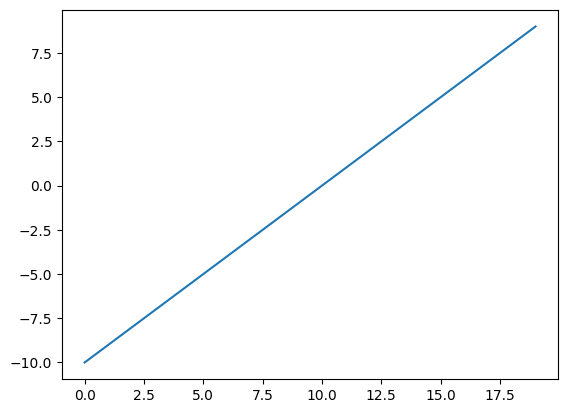

In [ ]:
plt.plot(A)

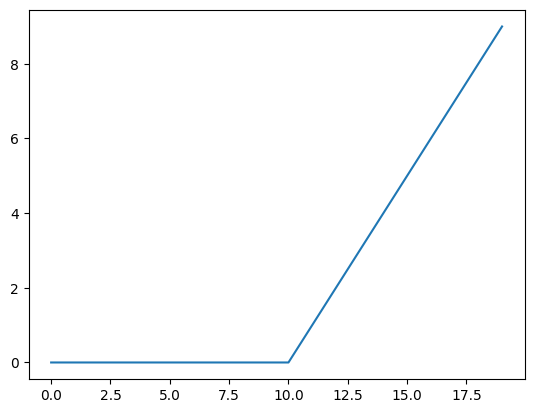

In [ ]:
plt.plot(torch.relu(A))

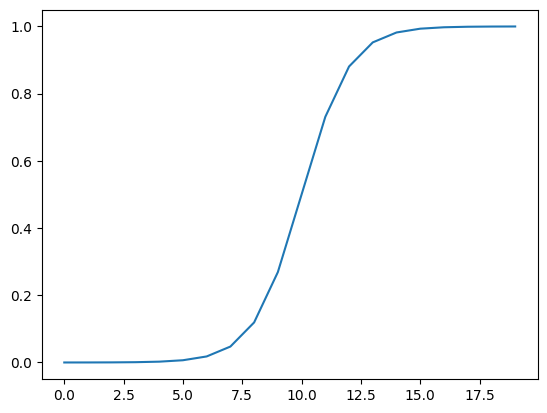

In [ ]:
plt.plot(torch.sigmoid(A))

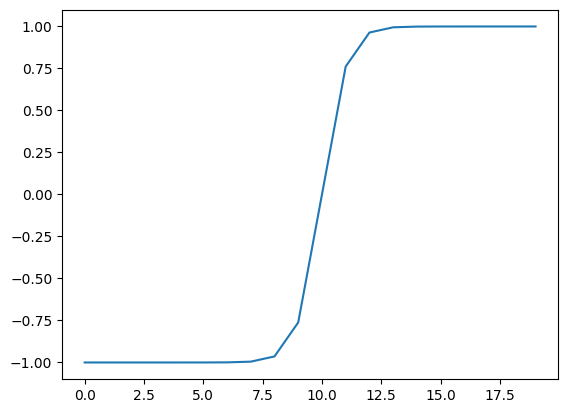

In [ ]:
plt.plot(torch.tanh(A))